# Aquino et al. 2023 (POPCELL): fourth replication cohort

Four parts, mirroring the manuscript:
1. Pseudobulk from the 6 GB count matrix (streamed, never loaded whole).
2. Diagnostic (cf. Fig 3B): does the baseline interferon score track run, post-thaw mortality,
   CMV or ancestry?
3. Technical unit (cf. Fig 2A): share of the difference between replicate libraries of the
   same sample that is due to the library itself.
4. Replication (cf. Fig 6B): baseline interferon vs shape deviation of the IAV and SARS-CoV-2
   responses, corrected pipeline, donors compared only within run.

Design notes (from 00_README.md): 222 donors, 6 h; each run thaws 16 donors, stimulates them
with NS, IAV or COV, pools 12 samples and processes every pool on two libraries. So every
donor x condition sample has two library replicates; we use them as independent halves.

In [52]:
# Cell 0 - config
import os, gzip, zipfile, time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

AQ = "data/aquino"
CACHE = os.path.join(AQ, "cache")
RES = "results/aquino"
os.makedirs(CACHE, exist_ok=True)
os.makedirs(RES, exist_ok=True)

SEED = 0
MIN_CELLS_DONOR = 50     # per donor x condition x lineage (all cells), as for Parse DEG/evaluation
MIN_CELLS_HALF = 20      # per library half after thinning
N_GENES = 2000
N_PERM = 10000
LINEAGES = ["B", "T.CD4", "T.CD8", "MONO", "NK"]
STIMS = ["IAV", "COV"]
ISGS = ["IFI27", "IFI44L", "IFI44", "IFI6", "IFIT1", "IFIT2", "IFIT3", "ISG15", "MX1", "MX2",
        "OAS1", "OAS2", "OAS3", "RSAD2", "HERC5", "XAF1", "EPSTI1", "CMPK2", "STAT1", "IFITM3"]
# Ensembl IDs of the ISGs (used when features.tsv has IDs but no symbols)
ISG_ENSG = {"IFI27": "ENSG00000165949", "IFI44L": "ENSG00000137959", "IFI44": "ENSG00000137965",
            "IFI6": "ENSG00000126709", "IFIT1": "ENSG00000185745", "IFIT2": "ENSG00000119922",
            "IFIT3": "ENSG00000119917", "ISG15": "ENSG00000187608", "MX1": "ENSG00000157601",
            "MX2": "ENSG00000183486", "OAS1": "ENSG00000089127", "OAS2": "ENSG00000111335",
            "OAS3": "ENSG00000111331", "RSAD2": "ENSG00000134321", "HERC5": "ENSG00000138646",
            "XAF1": "ENSG00000132530", "EPSTI1": "ENSG00000133106", "CMPK2": "ENSG00000134326",
            "STAT1": "ENSG00000115415", "IFITM3": "ENSG00000142089"}
BAD_BARCODES = {"ACTTCGCAGTAACGTA-L91", "AGCCAATGTAGGTTTC-L95", "ATTCCTAAGCCATATC-L96",
                "GCTACCTTCGTAGTGT-L96", "TCTACATCACCAACAT-L92"}

In [53]:
# Cell 1 - extract the matrix folder once (zip -> three .gz files, no decompression of .gz)
MTX_DIR = os.path.join(AQ, "filtered_count_matrix")
if not os.path.exists(os.path.join(MTX_DIR, "matrix.mtx.gz")):
    with zipfile.ZipFile(os.path.join(AQ, "filtered_count_matrix.zip")) as z:
        z.extractall(AQ)
print(os.listdir(MTX_DIR))

['matrix.mtx.gz', 'features.tsv.gz', 'barcodes.tsv.gz']


In [54]:
# Cell 2 - pseudobulk: donor x condition x lineage x library replicate x random half
# Run 16 (CITE-seq repeat of 16 donors) is excluded.
F_PB = os.path.join(CACHE, "pb_lineage_norun16.npz")
F_GR = os.path.join(CACHE, "pb_lineage_norun16_groups.csv")
F_GE = os.path.join(CACHE, "pb_lineage_norun16_genes.csv")

if not os.path.exists(F_PB):
    t0 = time.time()
    cm = pd.read_csv(os.path.join(AQ, "cell_metadata.tsv.gz"), sep="\t",
                     usecols=["Barcode", "Run", "Library", "Donor ID", "Condition", "lineage"])
    #print("cells before removing run 16:", f"{len(cm):,}")
    #cm = cm[cm["Run"] != 16].reset_index(drop=True)
    print("cells before removing run 16:", f"{len(cm):,}")
    sm0 = pd.read_csv(os.path.join(AQ, "sample_metadata.tsv.gz"), sep="\t")
    lib16 = set(sm0.loc[sm0["Run"] == 16, "Library"])
    print("run-16 libraries:", sorted(lib16))
    cm = cm[~cm["Library"].isin(lib16)].reset_index(drop=True)
    print("cells after removing run 16: ", f"{len(cm):,}")
    cm["key"] = cm["Barcode"] + "-" + cm["Library"]
    assert cm["key"].is_unique, "duplicate barcode-library keys"

    # library replicate index (0/1) within each donor x condition
    libs = (cm[["Donor ID", "Condition", "Library"]].drop_duplicates()
            .sort_values(["Donor ID", "Condition", "Library"]))
    libs["lib"] = libs.groupby(["Donor ID", "Condition"]).cumcount()
    n_lib = libs.groupby(["Donor ID", "Condition"])["lib"].max() + 1
    print("libraries per sample:", n_lib.value_counts().to_dict())
    libs["lib"] = libs["lib"] % 2          # if a sample has >2 libraries, alternate them
    cm = cm.merge(libs, on=["Donor ID", "Condition", "Library"], how="left")
    rng = np.random.default_rng(SEED)
    cm["half"] = rng.integers(0, 2, len(cm))

    gcols = ["Donor ID", "Condition", "lineage", "lib", "half"]
    gid, gtab = pd.MultiIndex.from_frame(cm[gcols]).factorize()
    cm["gid"] = gid
    groups = gtab.to_frame(index=False)
    groups.columns = gcols
    groups["ncells"] = np.bincount(gid, minlength=len(groups))

    bc = pd.read_csv(os.path.join(MTX_DIR, "barcodes.tsv.gz"), header=None)[0].astype(str)
    col2row = pd.Index(cm["key"]).get_indexer(bc)
    col2row[bc.isin(BAD_BARCODES).values] = -1
    print(f"matrix columns: {len(bc):,}; matched to cell metadata: {(col2row >= 0).sum():,}")
    col2gid = np.where(col2row >= 0, cm["gid"].values[np.maximum(col2row, 0)], -1).astype(np.int64)

    feats = pd.read_csv(os.path.join(MTX_DIR, "features.tsv.gz"), sep="\t", header=None,
                        keep_default_na=False, dtype=str)
    if feats.shape[1] >= 2:
        feats = feats.iloc[:, :2]
        feats.columns = ["gene_id", "symbol"]
    else:
        feats = pd.DataFrame({"gene_id": feats[0], "symbol": feats[0]})
    is_ens = feats["gene_id"].str.startswith("ENSG")
    if is_ens.mean() > 0.9:
        feats["human"] = is_ens
    else:
        VIRAL = {"PB2", "PB1", "PB1-F2", "PA", "PA-X", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP", "NS2",
                 "ORF1AB", "ORF1A", "S", "ORF3A", "E", "M", "ORF6", "ORF7A", "ORF7B", "ORF8", "N", "ORF10"}
        name = feats["symbol"].str.upper()
        feats["human"] = ~(name.isin(VIRAL) | name.str.contains("IAV|COV|SARS|VIRUS|FLU"))
    print("human genes:", feats["human"].sum(), "| viral:", (~feats["human"]).sum())
    G, NG = len(feats), len(groups)
    acc = np.zeros((NG, G), dtype=np.float64)

    with gzip.open(os.path.join(MTX_DIR, "matrix.mtx.gz"), "rb") as fh:
        line = fh.readline()
        while line.startswith(b"%"):
            line = fh.readline()
        nr, nc, nnz = map(int, line.split())
        assert nr == G and nc == len(bc), (nr, nc, G, len(bc))
        done = 0
        for ch in pd.read_csv(fh, sep=" ", header=None, names=["r", "c", "v"],
                              dtype={"r": np.int32, "c": np.int32, "v": np.int32},
                              chunksize=50_000_000, engine="c"):
            g = col2gid[ch["c"].values - 1]
            keep = g >= 0
            m = sp.coo_matrix((ch["v"].values[keep].astype(np.float64),
                               (g[keep], ch["r"].values[keep] - 1)), shape=(NG, G))
            m.sum_duplicates()
            acc[m.row, m.col] += m.data
            done += len(ch)
            print(f"\r{done/nnz:6.1%}  {(time.time()-t0)/60:5.1f} min", end="")
    print()
    np.savez_compressed(F_PB, counts=acc.astype(np.float32))
    groups.to_csv(F_GR, index=False)
    feats.to_csv(F_GE, index=False)

pb = np.load(F_PB)["counts"].astype(np.float64)
groups = pd.read_csv(F_GR)
genes = pd.read_csv(F_GE, keep_default_na=False)
human = genes["human"].astype(str).str.lower().eq("true")
print(pb.shape, groups.shape, "human genes:", human.sum())

cells before removing run 16: 1,047,819
run-16 libraries: ['L127', 'L128', 'L129', 'L130', 'L131', 'L132', 'L133', 'L134']
cells after removing run 16:  993,319
libraries per sample: {2: 656, 1: 10}
matrix columns: 1,047,824; matched to cell metadata: 993,319
human genes: 12665 | viral: 12
100.0%    7.3 min
(13170, 12677) (13170, 6) human genes: 12665


In [55]:
# Cell 3 - helpers
def collapse(by):
    """Sum pseudobulk rows over all group columns not in `by`."""
    key = pd.MultiIndex.from_frame(groups[by])
    idx, uniq = key.factorize()
    out = np.zeros((len(uniq), pb.shape[1]))
    np.add.at(out, idx, pb)
    tab = uniq.to_frame(index=False)
    tab.columns = by
    tab["ncells"] = np.bincount(idx, weights=groups["ncells"].values, minlength=len(uniq))
    return tab, out

def logcpm(c):
    """log2(CPM + 1) normalized on human genes only (viral reads excluded from library size)."""
    c = c[..., human.values]
    lib = c.sum(-1, keepdims=True)
    return np.log2(c / np.maximum(lib, 1) * 1e6 + 1)

def thin(c, p, rng):
    return rng.binomial(c.astype(np.int64), np.clip(p, 0, 1)).astype(np.float64)

def rank_within(x, strata):
    """Ranks centered within strata (for within-batch Spearman)."""
    s = pd.Series(x).groupby(pd.Series(strata)).rank()
    return (s - s.groupby(pd.Series(strata)).transform("mean")).values

def perm_within(x, strata, rng):
    x = np.asarray(x).copy()
    for s in np.unique(strata):
        i = np.where(strata == s)[0]
        x[i] = x[rng.permutation(i)]
    return x

def within_spearman(x, y, strata, n_perm=N_PERM, seed=SEED):
    """Spearman of within-stratum centered ranks; two-sided permutation p (x permuted within strata)."""
    ok = np.isfinite(x) & np.isfinite(y)
    x, y, strata = np.asarray(x)[ok], np.asarray(y)[ok], np.asarray(strata)[ok]
    ry = rank_within(y, strata)
    def r(xx):
        rx = rank_within(xx, strata)
        return np.corrcoef(rx, ry)[0, 1]
    obs = r(x)
    rng = np.random.default_rng(seed)
    null = np.array([r(perm_within(x, strata, rng)) for _ in range(n_perm)])
    p = (1 + np.sum(np.abs(null) >= abs(obs))) / (n_perm + 1)
    return obs, p, ok.sum()

def r2(y, X):
    X = np.column_stack([np.ones(len(y)), X]) if X.size else np.ones((len(y), 1))
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    return 1 - res.var() / y.var()

def dummies(s):
    return pd.get_dummies(pd.Series(s).astype(str), drop_first=True).values.astype(float)

In [56]:
# Cell 4 - donor table
sm = pd.read_csv(os.path.join(AQ, "sample_metadata.tsv.gz"), sep="\t")
s6 = sm[(sm["TP"] == "T6") & sm["in_final_dataset"] & (sm["Run"] != 16)]
#s6 = sm[(sm["TP"] == "T6") & sm["in_final_dataset"]]
donors = (s6.groupby("Donor ID")
          .agg(Run=("Run", "first"), n_runs=("Run", "nunique"), POP=("POP", "first"),
               Mortality=("Mortality", "mean"), Mortality_sd=("Mortality", "std"),
               CMV=("CMV", "first"), Age=("Age", "first"), GenderF=("GenderF", "first"))
          .reset_index())
print(donors.shape)
print("donors in >1 run:", (donors["n_runs"] > 1).sum(),
      "| mortality varies within donor:", (donors["Mortality_sd"].fillna(0) > 0).sum())
print(pd.crosstab(donors["Run"], donors["POP"]))
print(donors[["Mortality", "CMV", "Age"]].describe().T)

(222, 9)
donors in >1 run: 0 | mortality varies within donor: 0
POP  AFB  ASH  EUB
Run               
1      4    0    4
2      8    0    8
3      8    0    8
4      4    8    4
5      8    0    8
6      4    8    4
7      4    8    4
8      4    7    4
9      8    0    8
10     4    8    4
11     4    7    4
12     4    3    4
13     8    0    8
14     4    6    4
15     4    7    4
           count       mean       std   min   25%   50%    75%   max
Mortality  222.0   2.594595  3.045294   0.0   1.0   1.0   3.75  20.0
CMV        206.0   0.674757  0.469607   0.0   0.0   1.0   1.00   1.0
Age        222.0  33.774775  9.787502  19.0  27.0  31.0  39.75  64.0


In [69]:
# Plate layout check: is each condition tied to fixed wells across runs (as in Parse)?
s6w = sm[(sm["TP"] == "T6") & sm["in_final_dataset"] & (sm["Run"] != 16) & sm["Well"].notna()].copy()
s6w["row"], s6w["col"] = s6w["Well"].str[0], s6w["Well"].str[1:].astype(int)
w = s6w.drop_duplicates(["Run", "Donor ID", "Condition"])
print("samples with a well:", len(w), "| runs:", w["Run"].nunique(), "| distinct wells:", w["Well"].nunique())

top = w.groupby("Well")["Condition"].agg(lambda x: x.value_counts(normalize=True).iloc[0])
print("share of the most common condition per well: median", round(top.median(), 2), "| min", round(top.min(), 2))
print(pd.crosstab(w["col"], w["Condition"]))
print(pd.crosstab(w["row"], w["Condition"]))

lay = w.pivot_table(index=["Run", "Condition"], columns="Well", values="Donor ID", aggfunc="count").fillna(0) > 0
over = []
for cond in w["Condition"].unique():
    runs_c = [r for r in sorted(w["Run"].unique()) if (r, cond) in lay.index]
    for a, b in zip(runs_c[:-1], runs_c[1:]):
        A, B = lay.loc[(a, cond)].values, lay.loc[(b, cond)].values
        over.append((A & B).sum() / max(A.sum(), 1))
print("overlap of wells for the same condition in consecutive runs: median", round(np.median(over), 2))

samples with a well: 642 | runs: 14 | distinct wells: 16
share of the most common condition per well: median 0.33 | min 0.33
Condition  COV  IAV  NS
col                    
3           56   56  56
5           54   54  54
7           54   54  54
9           50   50  50
Condition  COV  IAV  NS
row                    
B           53   53  53
D           50   50  50
F           56   56  56
H           55   55  55
overlap of wells for the same condition in consecutive runs: median 1.0


In [57]:
# Cell 5 - baseline interferon score from NS cells (per lineage and donor-level)
tabD, cD = collapse(["Donor ID", "Condition", "lineage"])
ns = tabD["Condition"] == "NS"
L = logcpm(cD[ns.values])
sym = genes.loc[human.values, "symbol"].astype(str).values
gid_h = genes.loc[human.values, "gene_id"].astype(str).str.split(".").str[0].values
isg_idx = {g: np.where(sym == g)[0][0] for g in ISGS if g in set(sym)}
if len(isg_idx) < 10:   # features carry Ensembl IDs only
    isg_idx = {g: np.where(gid_h == e)[0][0] for g, e in ISG_ENSG.items() if e in set(gid_h)}
print("ISGs found:", len(isg_idx), "missing:", sorted(set(ISGS) - set(isg_idx)))
assert len(isg_idx) >= 10, "ISGs not found: check genes.head() and tell me what the gene names look like"
isg_idx = list(isg_idx.values())
print("lineages in data:", sorted(tabD["lineage"].unique()))

ifn = []
tns = tabD[ns].reset_index(drop=True)
for lin in LINEAGES:
    m = (tns["lineage"] == lin) & (tns["ncells"] >= MIN_CELLS_DONOR)
    X = L[m.values][:, isg_idx]
    Z = (X - X.mean(0)) / X.std(0)
    Z = Z[:, np.isfinite(Z).all(0)]          # drop ISGs with zero variance
    ifn.append(pd.DataFrame({"Donor ID": tns.loc[m, "Donor ID"].values, "lineage": lin,
                             "ifn": Z.mean(1)}))
ifn = pd.concat(ifn)
ifn_w = ifn.pivot(index="Donor ID", columns="lineage", values="ifn")
donors = donors.merge(ifn_w.mean(1).rename("ifn_raw"), left_on="Donor ID", right_index=True, how="left")
donors["ifn"] = (donors["ifn_raw"] - donors["ifn_raw"].mean()) / donors["ifn_raw"].std()
print("donors with a score:", donors["ifn"].notna().sum())
assert donors["ifn"].notna().sum() > 20, "no interferon scores: check the lineage names printed above"
print("correlation of the score between lineages (Spearman):")
print(ifn_w.corr(method="spearman").round(2))
donors.to_csv(os.path.join(RES, "donors_ifn.csv"), index=False)

ISGs found: 20 missing: []
lineages in data: ['B', 'MONO', 'NK', 'T.CD4', 'T.CD8']
donors with a score: 222
correlation of the score between lineages (Spearman):
lineage     B  MONO    NK  T.CD4  T.CD8
lineage                                
B        1.00  0.83  0.90   0.92   0.91
MONO     0.83  1.00  0.84   0.84   0.81
NK       0.90  0.84  1.00   0.94   0.93
T.CD4    0.92  0.84  0.94   1.00   0.96
T.CD8    0.91  0.81  0.93   0.96   1.00


/tmp/ipykernel_469683/2435877553.py:26: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  donors = donors.merge(ifn_w.mean(1).rename("ifn_raw"), left_on="Donor ID", right_index=True, how="left")


donors: 222
full model R2 = 0.184
   factor  R2_alone  R2_unique  df
      Run     0.153      0.155  14
      POP     0.008      0.028   2
Mortality     0.003      0.004   1
      CMV     0.001      0.002   1
  Age+Sex     0.001      0.004   2
Run        unique R2 permutation p = 0.0020
POP        unique R2 permutation p = 0.0330
Mortality  unique R2 permutation p = 0.3203
CMV        unique R2 permutation p = 0.4508
IFN vs mortality: Spearman 0.01 (p=0.919); within run 0.03 (perm p=0.694, n=222)
run means range: {'min': -0.86, 'max': 0.51}
POP means: {'AFB': -0.08, 'ASH': 0.13, 'EUB': -0.02}


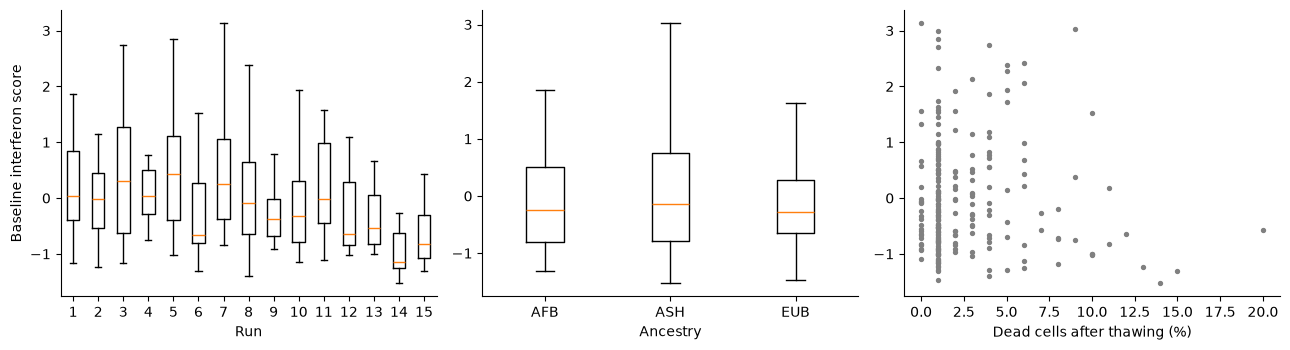

In [58]:
# Cell 6 - diagnostic: what does the baseline interferon score track?
d = donors.dropna(subset=["ifn", "Mortality"]).copy()
y = d["ifn"].values
print(f"donors: {len(d)}")

# variance explained, alone and on top of the others
facs = {"Run": dummies(d["Run"]), "POP": dummies(d["POP"]),
        "Mortality": d[["Mortality"]].values, "CMV": d[["CMV"]].fillna(d["CMV"].mean()).values,
        "Age+Sex": d[["Age", "GenderF"]].values}
allX = np.column_stack(list(facs.values()))
r2_full = r2(y, allX)
rows = []
for k, X in facs.items():
    rest = np.column_stack([v for kk, v in facs.items() if kk != k])
    rows.append({"factor": k, "R2_alone": r2(y, X), "R2_unique": r2_full - r2(y, rest),
                 "df": X.shape[1]})
diag = pd.DataFrame(rows)
print(f"full model R2 = {r2_full:.3f}")
print(diag.round(3).to_string(index=False))

# permutation p for Run and POP on top of the others (permute the factor labels)
rng = np.random.default_rng(SEED)
def perm_unique(k, n=2000):
    obs = diag.set_index("factor").loc[k, "R2_unique"]
    rest = np.column_stack([v for kk, v in facs.items() if kk != k])
    base = r2(y, rest)
    null = []
    for _ in range(n):
        Xp = facs[k][rng.permutation(len(y))]
        null.append(r2(y, np.column_stack([rest, Xp])) - base)
    return (1 + np.sum(np.array(null) >= obs)) / (n + 1)
for k in ["Run", "POP", "Mortality", "CMV"]:
    print(f"{k:10s} unique R2 permutation p = {perm_unique(k):.4f}")

# mortality: overall and within run
rho, p = stats.spearmanr(d["Mortality"], d["ifn"])
rw, pw, nw = within_spearman(d["Mortality"].values, d["ifn"].values, d["Run"].values)
print(f"IFN vs mortality: Spearman {rho:.2f} (p={p:.3g}); within run {rw:.2f} (perm p={pw:.3g}, n={nw})")
# run means vs ancestry means (cf. Fig 3B)
print("run means range:", d.groupby("Run")["ifn"].mean().agg(["min", "max"]).round(2).to_dict())
print("POP means:", d.groupby("POP")["ifn"].mean().round(2).to_dict())
diag.to_csv(os.path.join(RES, "ifn_diagnostic_r2.csv"), index=False)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
runs = sorted(d["Run"].unique())
ax[0].boxplot([d.loc[d["Run"] == r, "ifn"] for r in runs], showfliers=False)
ax[0].set_xticks(range(1, len(runs) + 1)); ax[0].set_xticklabels(runs)
ax[0].set_xlabel("Run"); ax[0].set_ylabel("Baseline interferon score")
pops = sorted(d["POP"].unique())
ax[1].boxplot([d.loc[d["POP"] == q, "ifn"] for q in pops], showfliers=False)
ax[1].set_xticks(range(1, len(pops) + 1)); ax[1].set_xticklabels(pops)
ax[1].set_xlabel("Ancestry")
ax[2].scatter(d["Mortality"], d["ifn"], s=8, c="grey")
ax[2].set_xlabel("Dead cells after thawing (%)")
for a in ax: a.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(os.path.join(RES, "aquino_ifn_diagnostic.png"), dpi=200)

In [59]:
# Cell 7 - technical unit: share of replicate-library differences due to the library (cf. Fig 2A)
# For each NS sample: four quarters = 2 libraries x 2 random halves, thinned to the same cell number.
# within = distance between halves of the same library; between = distance across libraries.
tabQ, cQ = collapse(["Donor ID", "Condition", "lineage", "lib", "half"])
rng = np.random.default_rng(SEED + 1)
tabNS, cNS = collapse(["Condition", "lineage"])
out = []
for lin in LINEAGES:
    t = tabQ[(tabQ["Condition"] == "NS") & (tabQ["lineage"] == lin)]
    i_ns = np.where((tabNS["Condition"] == "NS") & (tabNS["lineage"] == lin))[0]
    if len(i_ns) == 0:
        continue
    top = np.argsort(-logcpm(cNS[i_ns])[0])[:N_GENES]   # most expressed in NS, response-free
    res = []
    for dnr, tt in t.groupby("Donor ID"):
        if len(tt) != 4:
            continue
        n = tt["ncells"].min()
        if n < MIN_CELLS_HALF:
            continue
        q = {}
        for i, r in tt.iterrows():
            q[(r["lib"], r["half"])] = logcpm(thin(cQ[i], n / r["ncells"], rng)[None])[0][top]
        within = (np.sum((q[(0, 0)] - q[(0, 1)])**2) + np.sum((q[(1, 0)] - q[(1, 1)])**2)) / 2
        between = (np.sum((q[(0, 0)] - q[(1, 1)])**2) + np.sum((q[(0, 1)] - q[(1, 0)])**2)) / 2
        res.append((within, between, n))
    if res:
        w, b, n = map(np.array, zip(*res))
        out.append({"lineage": lin, "donors": len(w), "median_cells_per_quarter": int(np.median(n)),
                    "between/within": np.median(b / w),
                    "library_share": np.median((b - w) / b)})
lib_noise = pd.DataFrame(out)
print(lib_noise.round(3).to_string(index=False))
lib_noise.to_csv(os.path.join(RES, "library_share.csv"), index=False)

lineage  donors  median_cells_per_quarter  between/within  library_share
      B     157                        33           1.054          0.051
  T.CD4     218                       111           1.102          0.092
  T.CD8     217                        88           1.084          0.077
   MONO     178                        67           1.115          0.104
     NK     163                        41           1.050          0.048


In [60]:
# Cell 8 - replication: baseline interferon vs shape deviation (corrected pipeline)
# halves = the two library replicates (independent technical units), thinned to a common
# number of cells per half within lineage; reference = mean of the OTHER donors of the same run;
# cross-half estimators only, so sampling and library noise do not enter |z|^2 or z.m.
tabH, cH = collapse(["Donor ID", "Condition", "lineage", "lib"])
rng = np.random.default_rng(SEED + 2)
run_of = donors.set_index("Donor ID")["Run"]
results, per_donor = [], []

for lin in LINEAGES:
    for stim in STIMS:
        t = tabH[(tabH["lineage"] == lin) & tabH["Condition"].isin(["NS", stim])]
        wide = t.pivot_table(index="Donor ID", columns=["Condition", "lib"], values="ncells")
        need = [("NS", 0), ("NS", 1), (stim, 0), (stim, 1)]
        if not all(c in wide.columns for c in need):
            continue
        wide = wide[need].dropna()
        target = int(max(MIN_CELLS_HALF, np.quantile(wide.values.min(1), 0.10)))
        keep = wide.index[wide.values.min(1) >= target]
        # genes: expressed and variable across donors in this lineage (both conditions)
        rows = t[t["Donor ID"].isin(keep)].index
        Lr = logcpm(cH[rows])
        expr = (2**Lr - 1).mean(0) >= 10
        var = np.where(expr, Lr.var(0), -1)
        gsel = np.argsort(-var)[:N_GENES]

        H = {}
        for i in rows:
            r = t.loc[i]
            H[(r["Donor ID"], r["Condition"], r["lib"])] = \
                logcpm(thin(cH[i], target / r["ncells"], rng)[None])[0][gsel]
        dl = [dn for dn in keep if dn in run_of.index]
        A = np.array([H[(dn, stim, 0)] - H[(dn, "NS", 0)] for dn in dl])
        B = np.array([H[(dn, stim, 1)] - H[(dn, "NS", 1)] for dn in dl])
        runs_d = run_of.loc[dl].values

        rec = []
        for j, dn in enumerate(dl):
            oth = np.where((runs_d == runs_d[j]) & (np.arange(len(dl)) != j))[0]
            if len(oth) < 3:
                continue
            mA, mB = A[oth].mean(0), B[oth].mean(0)
            zz, mm = A[j] @ B[j], mA @ mB
            zm = (A[j] @ mB + B[j] @ mA) / 2
            if zz <= 0 or mm <= 0:
                rec.append((dn, np.nan, np.nan, zz)); continue
            cos = zm / np.sqrt(zz * mm)
            rec.append((dn, 1 - cos, np.sqrt(zz / mm), zz))
        pdn = pd.DataFrame(rec, columns=["Donor ID", "shape", "size_ratio", "zz"])
        pdn = pdn.merge(donors[["Donor ID", "Run", "POP", "ifn", "Mortality", "CMV"]], on="Donor ID")
        pdn["lineage"], pdn["stim"] = lin, stim
        per_donor.append(pdn)

        ok = pdn.dropna(subset=["shape", "ifn"])
        strata_run = ok["Run"].values
        strata_rp = (ok["Run"].astype(str) + "_" + ok["POP"]).values
        r_run, p_run, n = within_spearman(ok["ifn"].values, ok["shape"].values, strata_run)
        r_rp, p_rp, _ = within_spearman(ok["ifn"].values, ok["shape"].values, strata_rp)
        r_sz, p_sz, _ = within_spearman(ok["ifn"].values, np.log(ok["size_ratio"].values), strata_run)
        # Parse-style contrast: top quarter of interferon within run vs the rest
        hi = ok.groupby("Run")["ifn"].transform(lambda s: s >= s.quantile(0.75)).values
        diff = ok.loc[hi, "shape"].mean() - ok.loc[~hi, "shape"].mean()
        nd = [ok.loc[h, "shape"].mean() - ok.loc[~h, "shape"].mean()
              for h in (perm_within(hi, strata_run, np.random.default_rng(k)) for k in range(N_PERM))]
        p_hi = (1 + np.sum(np.array(nd) >= diff)) / (N_PERM + 1)
        results.append({"lineage": lin, "stim": stim, "donors": n, "cells_per_half": target,
                        "neg_zz": int((pdn["zz"] <= 0).sum()),
                        "rho_within_run": r_run, "p_within_run": p_run,
                        "rho_within_run_pop": r_rp, "p_within_run_pop": p_rp,
                        "rho_size_within_run": r_sz, "p_size": p_sz,
                        "shape_high_minus_rest": diff, "p_high_one_sided": p_hi})
        print(results[-1])

rep = pd.DataFrame(results)
per_donor = pd.concat(per_donor)
rep.to_csv(os.path.join(RES, "ifn_shape_replication.csv"), index=False)
per_donor.to_csv(os.path.join(RES, "ifn_shape_per_donor.csv"), index=False)
print(rep.round(3).to_string(index=False))

{'lineage': 'B', 'stim': 'IAV', 'donors': np.int64(193), 'cells_per_half': 26, 'neg_zz': 0, 'rho_within_run': np.float64(0.12459571846604035), 'p_within_run': np.float64(0.10278972102789721), 'rho_within_run_pop': np.float64(0.15352697095435683), 'p_within_run_pop': np.float64(0.08749125087491251), 'rho_size_within_run': np.float64(-0.5496688741721854), 'p_size': np.float64(9.999000099990002e-05), 'shape_high_minus_rest': np.float64(0.009358380106842867), 'p_high_one_sided': np.float64(0.05369463053694631)}
{'lineage': 'B', 'stim': 'COV', 'donors': np.int64(197), 'cells_per_half': 22, 'neg_zz': 0, 'rho_within_run': np.float64(-0.04678105294031383), 'p_within_run': np.float64(0.5511448855114488), 'rho_within_run_pop': np.float64(-0.07726931732933233), 'p_within_run_pop': np.float64(0.37846215378462156), 'rho_size_within_run': np.float64(-0.27056753189617244), 'p_size': np.float64(0.00029997000299970003), 'shape_high_minus_rest': np.float64(0.01574214421872362), 'p_high_one_sided': np.fl

In [61]:
# Cell 9 - sensitivity: same test controlling for mortality, CMV and ancestry (rank partial)
sens = []
for (lin, stim), g in per_donor.dropna(subset=["shape", "ifn", "Mortality"]).groupby(["lineage", "stim"]):
    ry = rank_within(g["shape"].values, g["Run"].values)
    rx = rank_within(g["ifn"].values, g["Run"].values)
    C = np.column_stack([rank_within(g["Mortality"].values, g["Run"].values),
                         g["CMV"].fillna(g["CMV"].mean()).values, dummies(g["POP"])])
    C = np.column_stack([np.ones(len(g)), C])
    res_x = rx - C @ np.linalg.lstsq(C, rx, rcond=None)[0]
    res_y = ry - C @ np.linalg.lstsq(C, ry, rcond=None)[0]
    r, p = stats.pearsonr(res_x, res_y)
    sens.append({"lineage": lin, "stim": stim, "partial_rho": r, "p": p, "n": len(g)})
sens = pd.DataFrame(sens)
print(sens.round(3).to_string(index=False))
sens.to_csv(os.path.join(RES, "ifn_shape_sensitivity.csv"), index=False)

lineage stim  partial_rho     p   n
      B  COV       -0.048 0.500 197
      B  IAV        0.119 0.100 193
   MONO  COV        0.128 0.082 186
   MONO  IAV        0.156 0.045 164
     NK  COV        0.106 0.145 192
     NK  IAV        0.078 0.279 193
  T.CD4  COV        0.148 0.040 192
  T.CD4  IAV        0.197 0.006 192
  T.CD8  COV        0.144 0.046 193
  T.CD8  IAV        0.133 0.065 193


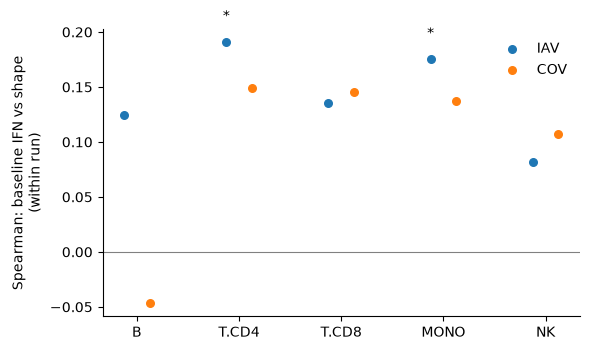

In [62]:
# Cell 10 - figure (cf. Fig 6B): within-run Spearman per lineage, IAV and COV
fig, ax = plt.subplots(figsize=(6, 3.6))
for k, stim in enumerate(STIMS):
    r = rep[rep["stim"] == stim]
    x = np.arange(len(r)) + (k - 0.5) * 0.25
    ax.scatter(x, r["rho_within_run"], label=stim, s=30)
    for xi, (_, row) in zip(x, r.iterrows()):
        if row["p_within_run"] < 0.05:
            ax.text(xi, row["rho_within_run"] + 0.02, "*", ha="center")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(np.arange(len(LINEAGES))); ax.set_xticklabels(LINEAGES)
ax.set_ylabel("Spearman: baseline IFN vs shape\n(within run)")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(os.path.join(RES, "aquino_ifn_shape.png"), dpi=200)

## Robustness of the interferon-shape association
High-IFN donors have much smaller responses (rho_size ~ -0.5). Two explanations must be excluded
before calling this a replication:
(a) ISG compression: virus responses are largely interferon responses, and genes already high at
    baseline cannot rise as much, which changes shape trivially -> rerun without IFN-linked genes.
(b) estimator bias: a smaller response with the same noise may bias the shape estimate
    -> empirical null with the real noise, the real sizes and NO shape difference.
(c) dependence on cells per half -> rerun with more cells (fewer donors).

In [63]:
# Cell 11 - reusable functions for the replication test
def halves(lin, stim, gene_mask=None, q=0.10, seed=SEED + 2):
    """Thinned library halves of the stim - NS response for one lineage."""
    rng = np.random.default_rng(seed)
    t = tabH[(tabH["lineage"] == lin) & tabH["Condition"].isin(["NS", stim])]
    wide = t.pivot_table(index="Donor ID", columns=["Condition", "lib"], values="ncells")
    need = [("NS", 0), ("NS", 1), (stim, 0), (stim, 1)]
    wide = wide[need].dropna()
    target = int(max(MIN_CELLS_HALF, np.quantile(wide.values.min(1), q)))
    keep = wide.index[wide.values.min(1) >= target]
    rows = t[t["Donor ID"].isin(keep)].index
    Lr = logcpm(cH[rows])
    ok = (2**Lr - 1).mean(0) >= 10
    if gene_mask is not None:
        ok &= gene_mask
    gsel = np.argsort(-np.where(ok, Lr.var(0), -1))[:N_GENES]
    H = {}
    for i in rows:
        r = t.loc[i]
        H[(r["Donor ID"], r["Condition"], r["lib"])] = \
            logcpm(thin(cH[i], target / r["ncells"], rng)[None])[0][gsel]
    dl = np.array([dn for dn in keep if dn in run_of.index])
    A = np.array([H[(dn, stim, 0)] - H[(dn, "NS", 0)] for dn in dl])
    B = np.array([H[(dn, stim, 1)] - H[(dn, "NS", 1)] for dn in dl])
    return dl, A, B, run_of.loc[dl].values, target

def shape_size(A, B, runs):
    shp, siz = np.full(len(A), np.nan), np.full(len(A), np.nan)
    for j in range(len(A)):
        oth = np.where((runs == runs[j]) & (np.arange(len(A)) != j))[0]
        if len(oth) < 3:
            continue
        mA, mB = A[oth].mean(0), B[oth].mean(0)
        zz, mm, zm = A[j] @ B[j], mA @ mB, (A[j] @ mB + B[j] @ mA) / 2
        if zz > 0 and mm > 0:
            shp[j], siz[j] = 1 - zm / np.sqrt(zz * mm), np.sqrt(zz / mm)
    return shp, siz

ifn_of = donors.set_index("Donor ID")["ifn"]
def test(dl, shp, runs, n_perm=N_PERM):
    x = ifn_of.loc[dl].values
    return within_spearman(x, shp, runs, n_perm=n_perm)

In [64]:
# Cell 12 - (a) remove interferon-linked genes
# genes whose baseline (NS) expression correlates with the IFN score in this lineage, plus the ISGs
def ifn_linked_mask(lin, thr=0.2):
    m = (tns["lineage"] == lin) & (tns["ncells"] >= MIN_CELLS_DONOR)
    X = L[m.values]
    s = ifn_of.loc[tns.loc[m, "Donor ID"].values].values
    Xr = np.apply_along_axis(stats.rankdata, 0, X)
    sr = stats.rankdata(s)
    rho = np.array([np.corrcoef(Xr[:, k], sr)[0, 1] if Xr[:, k].std() > 0 else 0 for k in range(X.shape[1])])
    linked = np.abs(np.nan_to_num(rho)) > thr
    linked[isg_idx] = True
    return ~linked, linked.sum()

rob = []
for lin in LINEAGES:
    mask, n_ex = ifn_linked_mask(lin)
    for stim in STIMS:
        dl, A, B, runs, tg = halves(lin, stim)
        shp, siz = shape_size(A, B, runs)
        r0, p0, n = test(dl, shp, runs)
        dl2, A2, B2, runs2, _ = halves(lin, stim, gene_mask=mask)
        shp2, _ = shape_size(A2, B2, runs2)
        r1, p1, _ = test(dl2, shp2, runs2)
        # (b) empirical null: true shape = 0, real sizes, real noise.
        # A' = s_d * m_run + noise_d, B' = s_d * m_run + noise_k (k: another donor, independent)
        rng = np.random.default_rng(SEED + 7)
        noise = (A - B) / np.sqrt(2)            # one-half noise of each donor, mean zero
        ok = np.isfinite(siz)
        nulls = []
        for rep_i in range(20):
            An, Bn = np.zeros_like(A), np.zeros_like(B)
            for j in range(len(A)):
                same = np.where(runs == runs[j])[0]
                m_run = (A[same].mean(0) + B[same].mean(0)) / 2
                s = siz[j] if ok[j] else 1.0
                k = rng.choice(np.delete(np.arange(len(A)), j))
                An[j] = s * m_run + noise[j] * rng.choice([-1, 1])
                Bn[j] = s * m_run + noise[k] * rng.choice([-1, 1])
            shn, _ = shape_size(An, Bn, runs)
            nulls.append(test(dl, shn, runs, n_perm=1)[0])
        # (c) more cells per half (median instead of 10th percentile)
        dl3, A3, B3, runs3, tg3 = halves(lin, stim, q=0.5)
        shp3, _ = shape_size(A3, B3, runs3)
        r3, p3, n3 = test(dl3, shp3, runs3)
        # (d) controlling for response size (partial, within run)
        okk = np.isfinite(shp) & np.isfinite(siz)
        rx = rank_within(ifn_of.loc[dl].values[okk], runs[okk])
        ry = rank_within(shp[okk], runs[okk]); rs = rank_within(np.log(siz[okk]), runs[okk])
        C = np.column_stack([np.ones(okk.sum()), rs])
        px = rx - C @ np.linalg.lstsq(C, rx, rcond=None)[0]
        py = ry - C @ np.linalg.lstsq(C, ry, rcond=None)[0]
        r4, p4 = stats.pearsonr(px, py)
        rob.append({"lineage": lin, "stim": stim, "n": n, "rho": r0, "p": p0,
                    "genes_excluded": n_ex, "rho_no_ifn_genes": r1, "p_no_ifn_genes": p1,
                    "null_rho_mean": np.mean(nulls), "null_rho_sd": np.std(nulls),
                    "cells_more": tg3, "n_more": n3, "rho_more_cells": r3, "p_more_cells": p3,
                    "rho_size_adjusted": r4, "p_size_adjusted": p4})
        print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in rob[-1].items()})
rob = pd.DataFrame(rob)
rob.to_csv(os.path.join(RES, "ifn_shape_robustness.csv"), index=False)
print(rob.round(3).to_string(index=False))

{'lineage': 'B', 'stim': 'IAV', 'n': np.int64(193), 'rho': np.float64(0.125), 'p': np.float64(0.103), 'genes_excluded': np.int64(656), 'rho_no_ifn_genes': np.float64(0.066), 'p_no_ifn_genes': np.float64(0.393), 'null_rho_mean': np.float64(0.003), 'null_rho_sd': np.float64(0.1), 'cells_more': 54, 'n_more': np.int64(109), 'rho_more_cells': np.float64(0.059), 'p_more_cells': np.float64(0.633), 'rho_size_adjusted': np.float64(0.127), 'p_size_adjusted': np.float64(0.079)}
{'lineage': 'B', 'stim': 'COV', 'n': np.int64(197), 'rho': np.float64(0.068), 'p': np.float64(0.361), 'genes_excluded': np.int64(656), 'rho_no_ifn_genes': np.float64(0.002), 'p_no_ifn_genes': np.float64(0.978), 'null_rho_mean': np.float64(-0.022), 'null_rho_sd': np.float64(0.071), 'cells_more': 54, 'n_more': np.int64(107), 'rho_more_cells': np.float64(0.044), 'p_more_cells': np.float64(0.724), 'rho_size_adjusted': np.float64(0.047), 'p_size_adjusted': np.float64(0.516)}
{'lineage': 'T.CD4', 'stim': 'IAV', 'n': np.int64(192

In [65]:
out = []
for lin in LINEAGES:
    mask, _ = ifn_linked_mask(lin)
    for stim in STIMS:
        for label, gm in [("all genes", None), ("no IFN genes", mask)]:
            dl, A, B, runs, _ = halves(lin, stim, gene_mask=gm)
            _, siz = shape_size(A, B, runs)
            r, p, n = within_spearman(ifn_of.loc[dl].values, np.log(siz), runs, n_perm=2000)
            out.append(dict(lineage=lin, stim=stim, genes=label, rho_size=r, p=p, n=n))
SIZE_AQ = pd.DataFrame(out).pivot_table(index=["lineage", "stim"], columns="genes", values=["rho_size", "p"])
SIZE_AQ.to_csv(os.path.join(RES, "ifn_size_aquino.csv"))
print(SIZE_AQ.round(3).to_string())

                     p               rho_size             
genes        all genes no IFN genes all genes no IFN genes
lineage stim                                              
B       COV      0.001        0.348    -0.231        0.071
        IAV      0.000        0.055    -0.550       -0.149
MONO    COV      0.008        0.960    -0.203       -0.005
        IAV      0.000        0.000    -0.628       -0.411
NK      COV      0.000        0.871    -0.422       -0.012
        IAV      0.000        0.012    -0.492       -0.195
T.CD4   COV      0.013        0.017    -0.183        0.183
        IAV      0.000        0.790    -0.495       -0.020
T.CD8   COV      0.028        0.077    -0.166        0.135
        IAV      0.000        0.265    -0.523       -0.084


In [66]:
def ifn_mask_frac(lin, frac):
    m = (tns["lineage"] == lin) & (tns["ncells"] >= MIN_CELLS_DONOR)
    X = L[m.values]
    s = ifn_of.loc[tns.loc[m, "Donor ID"].values].values
    expr = (2**X - 1).mean(0) >= 10                     # candidate genes, as in halves()
    Xr = np.apply_along_axis(stats.rankdata, 0, X); sr = stats.rankdata(s)
    rho = np.zeros(X.shape[1])
    for k in np.where(expr)[0]:
        if Xr[:, k].std() > 0:
            rho[k] = np.corrcoef(Xr[:, k], sr)[0, 1]
    cut = np.quantile(np.abs(rho[expr]), 1 - frac)
    linked = expr & (np.abs(rho) >= cut)
    linked[isg_idx] = True
    return ~linked

out = []
for lin in LINEAGES:
    for stim in STIMS:
        dl, A, B, runs, _ = halves(lin, stim)
        energy = np.median(np.sum(A * B, 1))           # response strength (for the COV question)
        for frac in [0.25, 0.40, 0.55]:
            dl2, A2, B2, runs2, _ = halves(lin, stim, gene_mask=ifn_mask_frac(lin, frac))
            _, siz = shape_size(A2, B2, runs2)
            r, p, n = within_spearman(ifn_of.loc[dl2].values, np.log(siz), runs2, n_perm=2000)
            out.append(dict(lineage=lin, stim=stim, response_energy=energy,
                            frac_removed=frac, rho_size=r, p=p, n=n))
FRAC_AQ = pd.DataFrame(out)
FRAC_AQ.to_csv(os.path.join(RES, "ifn_size_aquino_fractions.csv"), index=False)
print(FRAC_AQ.pivot_table(index=["lineage", "stim"], columns="frac_removed",
                          values=["rho_size", "p"]).round(3).to_string())
print(FRAC_AQ.groupby(["lineage", "stim"]).response_energy.first().round(1).unstack())

                  p               rho_size              
frac_removed   0.25   0.40   0.55     0.25   0.40   0.55
lineage stim                                            
B       COV   0.651  0.955  0.762    0.031 -0.004 -0.022
        IAV   0.137  0.047  0.043   -0.112 -0.149 -0.152
MONO    COV   0.573  0.694  0.676   -0.045 -0.032 -0.033
        IAV   0.000  0.000  0.000   -0.467 -0.466 -0.472
NK      COV   0.998  0.147  0.556   -0.000 -0.113 -0.046
        IAV   0.012  0.012  0.004   -0.194 -0.193 -0.223
T.CD4   COV   0.076  0.050  0.036    0.133  0.148  0.159
        IAV   0.341  0.430  0.303   -0.074 -0.062 -0.081
T.CD8   COV   0.063  0.092  0.074    0.140  0.127  0.136
        IAV   0.166  0.240  0.143   -0.105 -0.090 -0.111
stim        COV      IAV
lineage                 
B        3256.1   4229.4
MONO     8069.4  13122.3
NK       4222.6   6054.2
T.CD4    3227.5   4274.2
T.CD8    3281.4   3937.2


Parse fractions file: results/aim1/ifn_size_parse_fractions.csv
lineage stim        genes  rho_shape  p_shape  rho_size  p_size
      B  IAV    all genes      0.125    0.105    -0.550   0.000
      B  IAV no IFN genes      0.101    0.191    -0.149   0.047
      B  COV    all genes      0.068    0.366    -0.231   0.001
      B  COV no IFN genes      0.028    0.704    -0.004   0.955
  T.CD4  IAV    all genes      0.219    0.005    -0.495   0.000
  T.CD4  IAV no IFN genes      0.088    0.253    -0.062   0.430
  T.CD4  COV    all genes      0.191    0.014    -0.183   0.013
  T.CD4  COV no IFN genes      0.028    0.705     0.148   0.050
  T.CD8  IAV    all genes      0.083    0.284    -0.523   0.000
  T.CD8  IAV no IFN genes      0.050    0.485    -0.090   0.240
  T.CD8  COV    all genes      0.161    0.042    -0.166   0.028
  T.CD8  COV no IFN genes      0.070    0.360     0.127   0.092
   MONO  IAV    all genes      0.168    0.053    -0.628   0.000
   MONO  IAV no IFN genes      0.133    

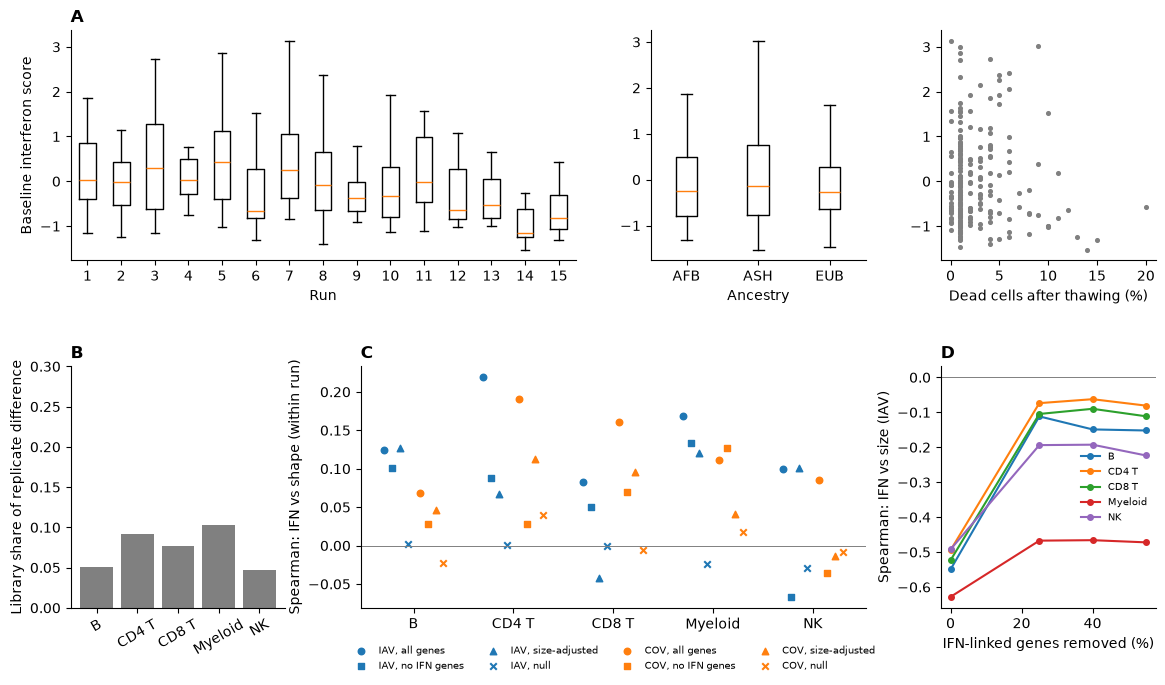

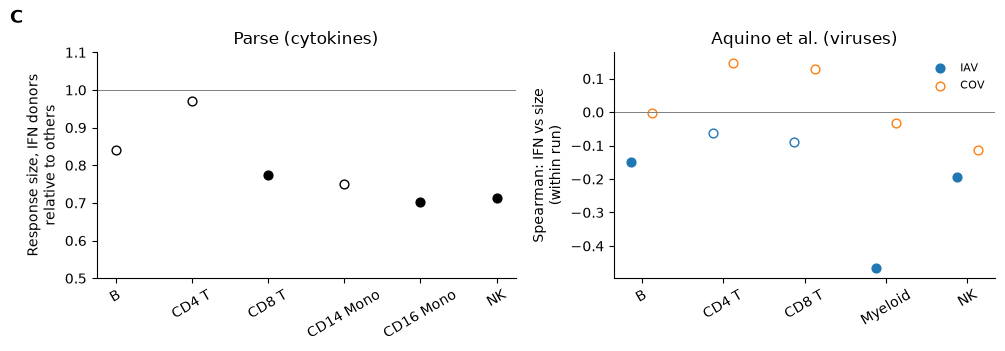

In [67]:
# %% Cell 13 - Figure S5 (Aquino) and Figure 6C (Parse + Aquino), 40% of genes removed as interferon-linked
# Needs Cells 0-12 and the fraction cell (ifn_mask_frac, FRAC_AQ) in memory.
# Parse input: the CSV written by the fraction cell of aim1_compass_parse.ipynb (set the path if different).
import glob
FRAC_MAIN = 0.40
PARSE_FRAC_CSV = (glob.glob("results/**/ifn_size_parse_fractions.csv", recursive=True) or [None])[0]
print("Parse fractions file:", PARSE_FRAC_CSV)

# ---- shape and size at 0% and 40% removal (recomputed so every panel uses the same rule)
rows = []
for lin in LINEAGES:
    keep40 = ifn_mask_frac(lin, FRAC_MAIN)
    for stim in STIMS:
        for label, gm in [("all genes", None), ("no IFN genes", keep40)]:
            dl, A, B, runs, _ = halves(lin, stim, gene_mask=gm)
            shp, siz = shape_size(A, B, runs)
            r_shape, p_shape, _ = within_spearman(ifn_of.loc[dl].values, shp, runs, n_perm=2000)
            r_size, p_size, _ = within_spearman(ifn_of.loc[dl].values, np.log(siz), runs, n_perm=2000)
            rows.append(dict(lineage=lin, stim=stim, genes=label, rho_shape=r_shape, p_shape=p_shape,
                             rho_size=r_size, p_size=p_size))
S40 = pd.DataFrame(rows)
S40.to_csv(os.path.join(RES, "ifn_shape_size_0_40.csv"), index=False)
print(S40.round(3).to_string(index=False))
rob_t = pd.read_csv(os.path.join(RES, "ifn_shape_robustness.csv"))

LAB = {"B": "B", "T.CD4": "CD4 T", "T.CD8": "CD8 T", "MONO": "Myeloid", "NK": "NK"}
COL = {"IAV": "#1f77b4", "COV": "#ff7f0e"}
def clean(a):
    a.spines[["top", "right"]].set_visible(False); a.axhline(0, color="grey", lw=0.7)

# ---- Figure S5
fig = plt.figure(figsize=(14, 7.5))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.05], hspace=0.45, wspace=0.35)
d = donors.dropna(subset=["ifn"])
ax = fig.add_subplot(gs[0, 0:2]); runs_ = sorted(d["Run"].unique())
ax.boxplot([d.loc[d["Run"] == r, "ifn"] for r in runs_], showfliers=False)
ax.set_xticks(range(1, len(runs_) + 1)); ax.set_xticklabels(runs_)
ax.set_xlabel("Run"); ax.set_ylabel("Baseline interferon score"); ax.set_title("A", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax = fig.add_subplot(gs[0, 2]); pops = sorted(d["POP"].unique())
ax.boxplot([d.loc[d["POP"] == q, "ifn"] for q in pops], showfliers=False)
ax.set_xticks(range(1, len(pops) + 1)); ax.set_xticklabels(pops); ax.set_xlabel("Ancestry")
ax.spines[["top", "right"]].set_visible(False)
ax = fig.add_subplot(gs[0, 3]); ax.scatter(d["Mortality"], d["ifn"], s=7, c="grey")
ax.set_xlabel("Dead cells after thawing (%)"); ax.spines[["top", "right"]].set_visible(False)

ax = fig.add_subplot(gs[1, 0]); ln = lib_noise.set_index("lineage").reindex(LINEAGES)
ax.bar(range(len(LINEAGES)), ln["library_share"], color="grey")
ax.set_xticks(range(len(LINEAGES))); ax.set_xticklabels([LAB[l] for l in LINEAGES], rotation=30)
ax.set_ylabel("Library share of replicate difference"); ax.set_ylim(0, max(0.3, ln["library_share"].max() * 1.2))
ax.set_title("B", loc="left", fontweight="bold"); ax.spines[["top", "right"]].set_visible(False)

ax = fig.add_subplot(gs[1, 1:3])
variants = [("all genes", "o"), ("no IFN genes", "s"), ("size-adjusted", "^"), ("null", "x")]
for k, stim in enumerate(STIMS):
    for v, (name, mk) in enumerate(variants):
        y = []
        for lin in LINEAGES:
            if name in ("all genes", "no IFN genes"):
                y.append(S40.query("lineage == @lin and stim == @stim and genes == @name").rho_shape.iloc[0])
            else:
                col = "rho_size_adjusted" if name == "size-adjusted" else "null_rho_mean"
                y.append(rob_t.query("lineage == @lin and stim == @stim")[col].iloc[0])
        x = np.arange(len(LINEAGES)) + (k - 0.5) * 0.36 + (v - 1.5) * 0.08
        ax.scatter(x, y, marker=mk, color=COL[stim], s=22,
                   label=f"{stim}, {name}" if True else None)
ax.set_xticks(range(len(LINEAGES))); ax.set_xticklabels([LAB[l] for l in LINEAGES])
ax.set_ylabel("Spearman: IFN vs shape (within run)"); clean(ax)
ax.legend(fontsize=7, ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12)); ax.set_title("C", loc="left", fontweight="bold")

ax = fig.add_subplot(gs[1, 3])
fr = pd.concat([S40.query("genes == 'all genes'").assign(frac_removed=0.0)[["lineage", "stim", "frac_removed", "rho_size", "p_size"]]
                .rename(columns={"p_size": "p"}), FRAC_AQ[["lineage", "stim", "frac_removed", "rho_size", "p"]]])
for lin in LINEAGES:
    g = fr.query("lineage == @lin and stim == 'IAV'").sort_values("frac_removed")
    ax.plot(g["frac_removed"] * 100, g["rho_size"], marker="o", ms=4, label=LAB[lin])
ax.set_xlabel("IFN-linked genes removed (%)"); ax.set_ylabel("Spearman: IFN vs size (IAV)")
clean(ax); ax.legend(fontsize=7, frameon=False); ax.set_title("D", loc="left", fontweight="bold")
fig.savefig(os.path.join(RES, "FigS5_aquino.png"), dpi=300, bbox_inches="tight")

# ---- Figure 6C
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [1.1, 1]})
if PARSE_FRAC_CSV:
    fp = pd.read_csv(PARSE_FRAC_CSV)
    fp = fp[np.isclose(fp["frac_removed"], FRAC_MAIN)].set_index("cell_type")
    order = [c for c in ["B", "CD4 T", "CD8 T", "CD14 Mono", "CD16 Mono", "NK"] if c in fp.index]
    for i, c in enumerate(order):
        sig = fp.loc[c, "p_smaller"] < 0.05
        ax[0].scatter(i, fp.loc[c, "size_ratio"], s=40, color="black",
                      facecolors="black" if sig else "white")
    ax[0].axhline(1, color="grey", lw=0.7); ax[0].set_ylim(min(0.5, fp["size_ratio"].min() - 0.05), 1.1)
    ax[0].set_xticks(range(len(order))); ax[0].set_xticklabels(order, rotation=30)
    ax[0].set_ylabel("Response size, IFN donors\nrelative to others"); ax[0].set_title("Parse (cytokines)")
    ax[0].spines[["top", "right"]].set_visible(False)
for k, stim in enumerate(STIMS):
    g = FRAC_AQ[np.isclose(FRAC_AQ["frac_removed"], FRAC_MAIN) & (FRAC_AQ["stim"] == stim)].set_index("lineage").reindex(LINEAGES)
    for i, lin in enumerate(LINEAGES):
        sig = g.loc[lin, "p"] < 0.05
        ax[1].scatter(i + (k - 0.5) * 0.25, g.loc[lin, "rho_size"], s=40, color=COL[stim],
                      facecolors=COL[stim] if sig else "white", label=stim if i == 0 else None)
ax[1].set_xticks(range(len(LINEAGES))); ax[1].set_xticklabels([LAB[l] for l in LINEAGES], rotation=30)
ax[1].set_ylabel("Spearman: IFN vs size\n(within run)"); ax[1].set_title("Aquino et al. (viruses)")
clean(ax[1]); ax[1].legend(frameon=False, fontsize=8)
fig.text(0.0, 0.98, "C", fontweight="bold", fontsize=13)
fig.tight_layout(); fig.savefig(os.path.join(RES, "Fig6C_size.png"), dpi=300, bbox_inches="tight")
print("saved:", os.path.join(RES, "FigS5_aquino.png"), os.path.join(RES, "Fig6C_size.png"))

In [68]:
# %% Cell 14 - naive vs corrected pipeline in Aquino (cf. Fig 3 / 1M-scBloodNL)
# naive   : unequal cell numbers (no thinning), reference = ALL other donors (no run strata),
#           asymmetric estimator (one half vs the reference, noise term from the two halves)
# corrected: as in Cell 8 (thinning, cross-half estimator, other donors of the same run)
ifn_of = donors.set_index("Donor ID")["ifn"]
def naive_shape(lin, stim):
    t = tabH[(tabH["lineage"] == lin) & tabH["Condition"].isin(["NS", stim])]
    wide = t.pivot_table(index="Donor ID", columns=["Condition", "lib"], values="ncells")
    need = [("NS", 0), ("NS", 1), (stim, 0), (stim, 1)]
    wide = wide[need].dropna()
    keep = wide.index[wide.values.min(1) >= MIN_CELLS_HALF]
    rows = t[t["Donor ID"].isin(keep)].index
    Lr = logcpm(cH[rows]); ok = (2**Lr - 1).mean(0) >= 10
    gsel = np.argsort(-np.where(ok, Lr.var(0), -1))[:N_GENES]
    H = {(t.loc[i, "Donor ID"], t.loc[i, "Condition"], t.loc[i, "lib"]): logcpm(cH[i][None])[0][gsel] for i in rows}
    dl = np.array([d for d in keep if d in run_of.index])
    A = np.array([H[(d, stim, 0)] - H[(d, "NS", 0)] for d in dl])
    B = np.array([H[(d, stim, 1)] - H[(d, "NS", 1)] for d in dl])
    F = (A + B) / 2
    shp = np.full(len(dl), np.nan)
    for j in range(len(dl)):
        m = np.delete(F, j, 0).mean(0)
        zz = F[j] @ F[j] - np.sum((A[j] - B[j]) ** 2) / 4          # noise-corrected squared norm
        if zz > 0:
            shp[j] = 1 - (A[j] @ m) / np.sqrt(zz * (m @ m))
    cells = wide.loc[dl].values.sum(1)
    return dl, shp, cells

out = []
for lin in LINEAGES:
    for stim in STIMS:
        dl, shp, cells = naive_shape(lin, stim)
        ok = np.isfinite(shp)
        x = ifn_of.loc[dl].values
        r_n, p_n = stats.spearmanr(x[ok], shp[ok])
        r_c, _ = stats.spearmanr(x, cells)                              # do high-IFN donors have fewer cells?
        neg = np.mean(~ok)
        rc = rep.query("lineage == @lin and stim == @stim")
        out.append(dict(lineage=lin, stim=stim, rho_naive=r_n, p_naive=p_n, invalid_naive=neg,
                        rho_ifn_vs_cells=r_c,
                        rho_corrected=rc["rho_within_run"].iloc[0], p_corrected=rc["p_within_run"].iloc[0]))
NAIVE = pd.DataFrame(out)
NAIVE.to_csv(os.path.join(RES, "naive_vs_corrected.csv"), index=False)
print(NAIVE.round(3).to_string(index=False))

lineage stim  rho_naive  p_naive  invalid_naive  rho_ifn_vs_cells  rho_corrected  p_corrected
      B  IAV      0.009    0.902          0.000             0.011          0.125        0.103
      B  COV      0.096    0.170          0.005             0.033         -0.047        0.551
  T.CD4  IAV      0.229    0.001          0.000            -0.106          0.191        0.015
  T.CD4  COV      0.073    0.284          0.000            -0.095          0.149        0.052
  T.CD8  IAV      0.128    0.061          0.000            -0.121          0.136        0.080
  T.CD8  COV      0.093    0.176          0.000            -0.083          0.146        0.054
   MONO  IAV      0.139    0.076          0.000             0.065          0.175        0.045
   MONO  COV      0.183    0.012          0.000             0.031          0.138        0.084
     NK  IAV      0.062    0.388          0.000            -0.129          0.082        0.292
     NK  COV     -0.082    0.247          0.000            -

In [70]:
# %% Cell 15 - monocytes only (myeloid lineage without dendritic cells)
# The MONO lineage of Aquino et al. includes cDCs and pDCs. This cell rebuilds pseudobulks for monocytes
# only (celltype names containing "MONO"), adds them as an extra lineage "MONOCYTE", and repeats the
# response-size test with 0, 25, 40 and 55% of genes removed as interferon-linked, and the shape test.
# Needs Cells 0-12 and the fraction cell (ifn_mask_frac) in memory. One pass over the matrix (~8 min).
F_PBM = os.path.join(CACHE, "pb_monocytes_norun16.npz")
F_GRM = os.path.join(CACHE, "pb_monocytes_norun16_groups.csv")

if not os.path.exists(F_PBM):
    t0 = time.time()
    cmm = pd.read_csv(os.path.join(AQ, "cell_metadata.tsv.gz"), sep="\t",
                      usecols=["Barcode", "Library", "Donor ID", "Condition", "lineage", "celltype"])
    sm0 = pd.read_csv(os.path.join(AQ, "sample_metadata.tsv.gz"), sep="\t")
    cmm = cmm[~cmm["Library"].isin(set(sm0.loc[sm0["Run"] == 16, "Library"]))].reset_index(drop=True)
    print("cell types in the MONO lineage:")
    print(cmm.loc[cmm["lineage"] == "MONO", "celltype"].value_counts().to_string())
    # library index exactly as in Cell 2 (computed on all cells before selecting monocytes)
    libs = (cmm[["Donor ID", "Condition", "Library"]].drop_duplicates()
            .sort_values(["Donor ID", "Condition", "Library"]))
    libs["lib"] = libs.groupby(["Donor ID", "Condition"]).cumcount() % 2
    cmm = cmm.merge(libs, on=["Donor ID", "Condition", "Library"], how="left")
    is_mono = (cmm["lineage"] == "MONO") & cmm["celltype"].astype(str).str.upper().str.contains("MONO")
    print(f"monocytes kept: {is_mono.sum():,} of {(cmm['lineage'] == 'MONO').sum():,} myeloid cells")
    cmm = cmm[is_mono].reset_index(drop=True)
    cmm["lineage"] = "MONOCYTE"
    cmm["half"] = np.random.default_rng(SEED + 5).integers(0, 2, len(cmm))
    cmm["key"] = cmm["Barcode"] + "-" + cmm["Library"]

    gcols = ["Donor ID", "Condition", "lineage", "lib", "half"]
    gid, gtab = pd.MultiIndex.from_frame(cmm[gcols]).factorize()
    gm = gtab.to_frame(index=False); gm.columns = gcols
    gm["ncells"] = np.bincount(gid, minlength=len(gm))
    bc = pd.read_csv(os.path.join(MTX_DIR, "barcodes.tsv.gz"), header=None)[0].astype(str)
    col2row = pd.Index(cmm["key"]).get_indexer(bc)
    col2gid = np.where(col2row >= 0, gid[np.maximum(col2row, 0)], -1).astype(np.int64)
    G, NG = len(genes), len(gm)
    accm = np.zeros((NG, G))
    with gzip.open(os.path.join(MTX_DIR, "matrix.mtx.gz"), "rb") as fh:
        line = fh.readline()
        while line.startswith(b"%"):
            line = fh.readline()
        nr, nc, nnz = map(int, line.split())
        done = 0
        for ch in pd.read_csv(fh, sep=" ", header=None, names=["r", "c", "v"],
                              dtype={"r": np.int32, "c": np.int32, "v": np.int32},
                              chunksize=50_000_000, engine="c"):
            g = col2gid[ch["c"].values - 1]; k = g >= 0
            m = sp.coo_matrix((ch["v"].values[k].astype(np.float64), (g[k], ch["r"].values[k] - 1)), shape=(NG, G))
            m.sum_duplicates(); accm[m.row, m.col] += m.data
            done += len(ch); print(f"\r{done/nnz:6.1%}  {(time.time()-t0)/60:5.1f} min", end="")
    print()
    np.savez_compressed(F_PBM, counts=accm.astype(np.float32)); gm.to_csv(F_GRM, index=False)

# add the monocyte groups as an extra lineage and rebuild the derived tables
pbm = np.load(F_PBM)["counts"].astype(np.float64)
gm = pd.read_csv(F_GRM)
if "MONOCYTE" not in set(groups["lineage"]):
    pb = np.vstack([pb, pbm])
    groups = pd.concat([groups, gm], ignore_index=True)
tabH, cH = collapse(["Donor ID", "Condition", "lineage", "lib"])
tabD, cD = collapse(["Donor ID", "Condition", "lineage"])
ns = tabD["Condition"] == "NS"
L = logcpm(cD[ns.values]); tns = tabD[ns].reset_index(drop=True)
print("monocyte donors with >= 50 NS cells:",
      ((tns["lineage"] == "MONOCYTE") & (tns["ncells"] >= MIN_CELLS_DONOR)).sum())

rows = []
for lin in ["MONO", "MONOCYTE"]:
    for stim in STIMS:
        dl, A, B, runs, tg = halves(lin, stim)
        shp, siz = shape_size(A, B, runs)
        r_sh, p_sh, n = within_spearman(ifn_of.loc[dl].values, shp, runs, n_perm=2000)
        r0, p0, _ = within_spearman(ifn_of.loc[dl].values, np.log(siz), runs, n_perm=2000)
        row = dict(lineage=lin, stim=stim, donors=n, cells_per_half=tg, rho_shape=r_sh, p_shape=p_sh,
                   rho_size_0=r0, p_size_0=p0)
        for frac in [0.25, 0.40, 0.55]:
            dl2, A2, B2, runs2, _ = halves(lin, stim, gene_mask=ifn_mask_frac(lin, frac))
            _, siz2 = shape_size(A2, B2, runs2)
            r, p, _ = within_spearman(ifn_of.loc[dl2].values, np.log(siz2), runs2, n_perm=2000)
            row[f"rho_size_{int(frac*100)}"], row[f"p_size_{int(frac*100)}"] = r, p
        rows.append(row)
MONO_CHECK = pd.DataFrame(rows)
MONO_CHECK.to_csv(os.path.join(RES, "monocytes_only_check.csv"), index=False)
print(MONO_CHECK.round(3).T.to_string())

# combined with Parse (40% removed), as in the paper
p40 = MONO_CHECK.query("lineage == 'MONOCYTE' and stim == 'IAV'").iloc[0]
p_one = p40["p_size_40"] / 2 if p40["rho_size_40"] < 0 else 1 - p40["p_size_40"] / 2
for name, pp in [("Parse CD14 Mono", 0.081), ("Parse CD16 Mono", 0.030)]:
    print(f"Fisher, {name} + Aquino monocytes (IAV, 40%): p = {stats.combine_pvalues([pp, p_one], method='fisher')[1]:.5f}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
cell types in the MONO lineage:
celltype
MONO.CD14             112884
MONO.CD16              22999
MONO.CD14.INFECTED      7890
cDC                     2115
pDC                     1163
monocytes kept: 143,773 of 147,051 myeloid cells
100.0%    3.9 min
monocyte donors with >= 50 NS cells: 201
                    0      1         2         3
lineage          MONO   MONO  MONOCYTE  MONOCYTE
stim              IAV    COV       IAV       COV
donors            164    186       164       186
cells_per_half     20     20        20        20
rho_shape       0.168  0.112     0.191      0.15
p_shape         0.053  0.153     0.029     0.058
rho_size_0     -0.628 -0.203     -0.66      -0.2
p_size_0          0.0  0.008       0.0     0.009
rho_size_25    -0.467 -0.045    -0.527    -0.055
p_size_25         0.0  0.573       0.0     0.493
rho_size_40  